## ใบงานที่3: Regression & Classification
### วิชา Machine Learning (04-624-201)

---

Dataset : UTKFace (Aligned & Cropped)

  ลิ้งค์อ้างอิง : https://www.kaggle.com/datasets/moritzm00/utkface-cropped

#### Data Preparation 

อันนี้คือการโหลดเตรียมข้อมูลสำหรับแต่ละแลป

In [30]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
plt.rcParams['font.family'] = 'Tahoma'  

โหลดรายชื่อไฟล์ และดึง Label อายุ+เพศจากชื่อไฟล์ของdataset

In [5]:
data_dir = "UTKFace"

image_files = os.listdir(data_dir)
print("จำนวนไฟล์ทั้งหมด:", len(image_files))
print("ตัวอย่างชื่อไฟล์ 5 อัน:", image_files[:5])

จำนวนไฟล์ทั้งหมด: 23708
ตัวอย่างชื่อไฟล์ 5 อัน: ['100_0_0_20170112213500903.jpg.chip.jpg', '100_0_0_20170112215240346.jpg.chip.jpg', '100_1_0_20170110183726390.jpg.chip.jpg', '100_1_0_20170112213001988.jpg.chip.jpg', '100_1_0_20170112213303693.jpg.chip.jpg']


#### DataFrame

การดึง Age และ Gender ออกมาเป็นตาราง

In [6]:
ages = []
genders = []
image_paths = []

for file in image_files:
    try:
        parts = file.split("_")
        age = int(parts[0])
        gender = int(parts[1])
        ages.append(age)
        genders.append(gender)
        image_paths.append(os.path.join(data_dir, file))
    except:
        continue  

df = pd.DataFrame({
    "path": image_paths,
    "age": ages,
    "gender": genders
})

print("จำนวนภาพที่แปลง label สำเร็จ:", len(df))
df.head()

จำนวนภาพที่แปลง label สำเร็จ: 23708


,path,age,gender
0,UTKFace\100_0_0_20170112213500903.jpg.chip.jpg,100,0
1,UTKFace\100_0_0_20170112215240346.jpg.chip.jpg,100,0
2,UTKFace\100_1_0_20170110183726390.jpg.chip.jpg,100,1
3,UTKFace\100_1_0_20170112213001988.jpg.chip.jpg,100,1
4,UTKFace\100_1_0_20170112213303693.jpg.chip.jpg,100,1


ดู EDA เบื้องต้น (การกระจายตัวของอายุ) ก่อนสร้างโมเดล ควรดูข้อมูลก่อนเสมอ

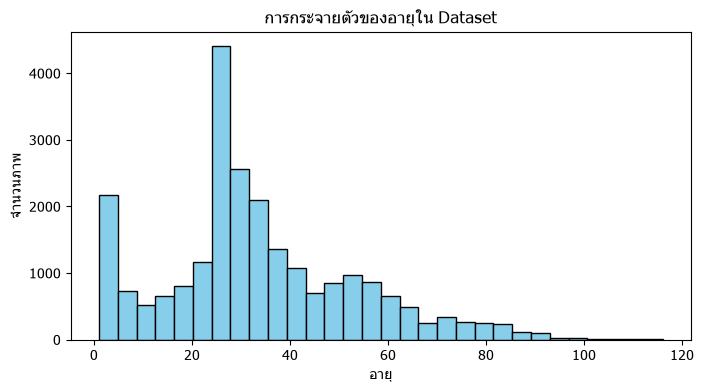

count    23708.000000
mean        33.303484
std         19.886112
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


In [9]:
plt.figure(figsize=(8,4))
plt.hist(df["age"], bins=30, color="skyblue", edgecolor="black")
plt.title("การกระจายตัวของอายุใน Dataset")
plt.xlabel("อายุ")
plt.ylabel("จำนวนภาพ")
plt.show()

print(df["age"].describe())

#### LAB1 : Regression

#### 1.1 Simple Linear Regression  

การแปลงรูปภาพเป็นตัวเลข (Feature)

In [10]:
def get_mean_brightness(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))
    return np.mean(img)

df_sample = df.sample(3000, random_state=42).reset_index(drop=True)
df_sample["brightness"] = df_sample["path"].apply(get_mean_brightness)

df_sample.head()

,path,age,gender,brightness
0,UTKFace\49_1_0_20170104185652921.jpg.chip.jpg,49,1,121.243652
1,UTKFace\17_1_0_20170109214200825.jpg.chip.jpg,17,1,69.158691
2,UTKFace\17_1_4_20170103201233799.jpg.chip.jpg,17,1,123.012939
3,UTKFace\29_0_4_20170103235921692.jpg.chip.jpg,29,0,76.741943
4,UTKFace\26_1_2_20170116180208093.jpg.chip.jpg,26,1,164.999023


การสร้าง, เทรน (Training), และประเมินผลโมเดล Simple Linear Regression แบบตัวแปรเดียว เพื่อดูว่า ความสว่างของภาพ (Brightness) สามารถนำมาใช้ทำนาย อายุ (Age) ได้มากน้อยเพียงใด

In [11]:
X = df_sample[["brightness"]]   
y = df_sample["age"]            

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("ค่า Coefficient (w):", model.coef_)
print("ค่า Intercept (b):", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

ค่า Coefficient (w): [-0.09645377]
ค่า Intercept (b): 45.52363001369273
MSE: 400.5517830462807
R2 Score: 0.022608870083858923


การสร้าง Scatter Plot พร้อมเส้นสมการถดถอย (Regression Line) เพื่อแสดงความสัมพันธ์ระหว่าง ความสว่างของภาพ (Brightness) กับ อายุ (Age) ในโมเดล Simple Linear Regression

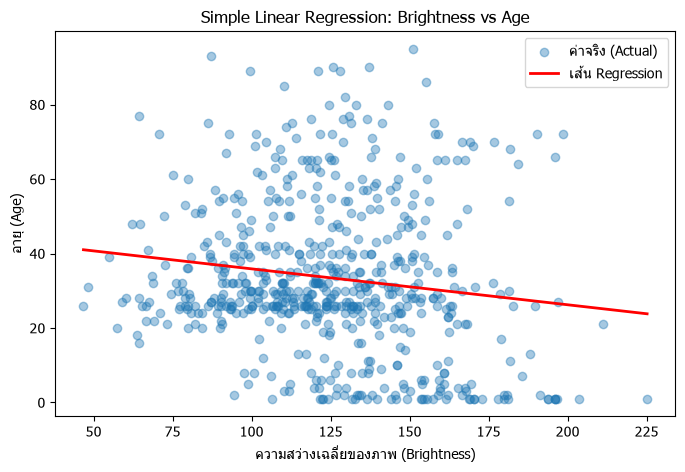

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, alpha=0.4, label="ค่าจริง (Actual)")

X_range = pd.DataFrame(sorted(X_test["brightness"]), columns=["brightness"])
plt.plot(X_range, model.predict(X_range), color="red", linewidth=2, label="เส้น Regression")

plt.xlabel("ความสว่างเฉลี่ยของภาพ (Brightness)")
plt.ylabel("อายุ (Age)")
plt.title("Simple Linear Regression: Brightness vs Age")
plt.legend()
plt.show()

อธิบาย:
จุดสีฟ้า (scatter) = ข้อมูลจริงจาก test set (brightness คู่กับ age จริง)

เส้นสีแดง = เส้นตรงที่โมเดลเรียนรู้มา

ถ้าเห็นว่าจุดสีฟ้ากระจัดกระจายไปทั่ว ไม่เกาะกลุ่มตามเส้นแดงเลย นั่นคือภาพที่ยืนยัน R² ต่ำที่เราเพิ่งคำนวณได้

#### 1.2 Multiple Linear Regression  

การแปลงภาพถ่ายให้เป็นข้อมูลตัวเลข (Feature Extraction) เพื่อนำไปใช้งานต่อในโมเดล Machine Learning

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_pixel_array(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))
    return img.flatten()   

pixel_data = np.array([get_pixel_array(p) for p in df_sample["path"]])

print("ขนาดของข้อมูลพิกเซลทั้งหมด:", pixel_data.shape)

ขนาดของข้อมูลพิกเซลทั้งหมด: (3000, 4096)


การทำ PCA ลดมิติข้อมูล

-นี่คือหัวใจของ PCA: ลดขนาดข้อมูลมหาศาล แต่ยังรักษา "สาระสำคัญ" ไว้ได้เกือบครบ

ลองรันแล้วส่งผลลัพธ์ทั้ง 3 บรรทัด โดยเฉพาะตัวเลข % ความแปรปรวนที่อธิบายได้

In [14]:
scaler = StandardScaler()
pixel_scaled = scaler.fit_transform(pixel_data)

pca = PCA(n_components=50, random_state=42)
pixel_pca = pca.fit_transform(pixel_scaled)

print("ขนาดข้อมูลก่อนทำ PCA:", pixel_scaled.shape)
print("ขนาดข้อมูลหลังทำ PCA:", pixel_pca.shape)
print("ทั้ง 50 components อธิบายความแปรปรวนรวมได้:", 
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

ขนาดข้อมูลก่อนทำ PCA: (3000, 4096)
ขนาดข้อมูลหลังทำ PCA: (3000, 50)
ทั้ง 50 components อธิบายความแปรปรวนรวมได้: 87.75 %


การ เตรียมข้อมูล, เทรน (Training), ทำนาย (Prediction), และประเมินผล โมเดล Multiple Linear Regression สำหรับการทำนายอายุโดยใช้ฟีเจอร์จาก PCA

In [15]:
X_multi = pixel_pca                   
y_multi = df_sample["age"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_m = model_multi.predict(X_test_m)

print("MSE (Multiple):", mean_squared_error(y_test_m, y_pred_m))
print("R2 Score (Multiple):", r2_score(y_test_m, y_pred_m))

MSE (Multiple): 251.95300367535634
R2 Score (Multiple): 0.38520650419980995


การสร้าง Scatter Plot เปรียบเทียบระหว่างค่าจริงกับค่าที่โมเดลทำนาย (Actual vs. Predicted Plot) เพื่อประเมินความแม่นยำของโมเดล

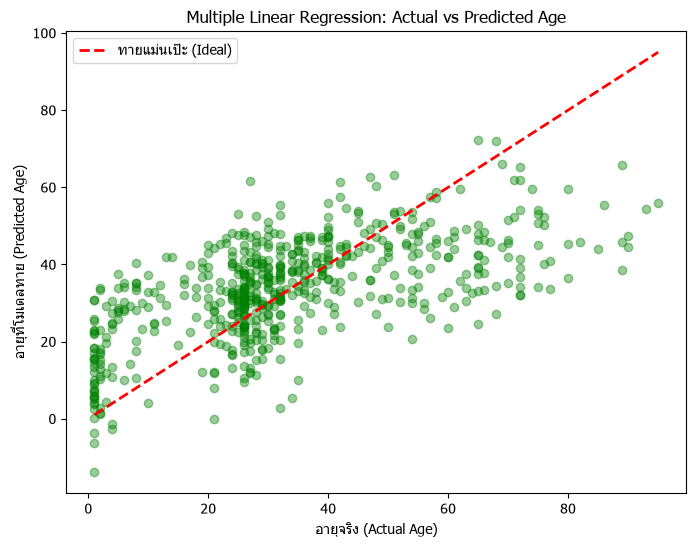

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_m, y_pred_m, alpha=0.4, color="green")

min_age, max_age = y_test_m.min(), y_test_m.max()
plt.plot([min_age, max_age], [min_age, max_age], color="red", linewidth=2, linestyle="--", label="ทายแม่นเป๊ะ (Ideal)")

plt.xlabel("อายุจริง (Actual Age)")
plt.ylabel("อายุที่โมเดลทาย (Predicted Age)")
plt.title("Multiple Linear Regression: Actual vs Predicted Age")
plt.legend()
plt.show()

เห็นแนวโน้มชัดเจนว่า จุดสีเขียวเกาะเป็นแนวเฉียงตามเส้นแดงพอสมควร (ต่างจาก 1.1 ที่กระจัดกระจายเป็นก้อนสี่เหลี่ยมไม่มีทิศทาง) ยืนยันว่าโมเดลนี้ "เรียนรู้บางอย่างได้จริง" ไม่ใช่การทายมั่วๆ

#### 1.3 Age Prediction  

การสร้าง ตารางเปรียบเทียบผลลัพธ์ (Performance Comparison Table) ระหว่างโมเดลอย่างง่ายที่ใช้เพียงค่าความสว่าง กับโมเดลที่ใช้มิติข้อมูลจาก PCA

In [17]:
comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression (Brightness)", "Multiple Linear Regression (PCA 50 features)"],
    "MSE": [mean_squared_error(y_test, y_pred), mean_squared_error(y_test_m, y_pred_m)],
    "R2 Score": [r2_score(y_test, y_pred), r2_score(y_test_m, y_pred_m)]
})

comparison

,Model,MSE,R2 Score
0,Simple Linear Regression (Brightness),400.551783,0.022609
1,Multiple Linear Regression (PCA 50 features),251.953004,0.385207


การสุ่มภาพตัวอย่างจาก Test Set มาทดลองทำนายผลลัพธ์ (Qualitative Evaluation) โดยนำภาพมาแสดงผลพร้อมเปรียบเทียบ อายุจริง กับ อายุที่โมเดลทาย

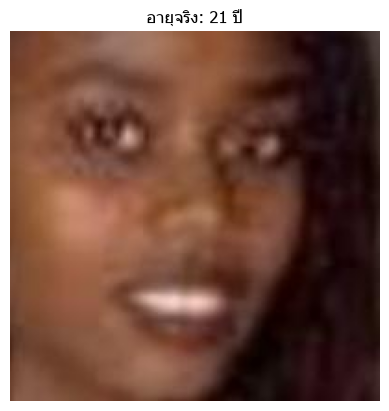

อายุจริง: 21 ปี
อายุที่โมเดลทาย: 29.5 ปี
คลาดเคลื่อน: 8.5 ปี


In [19]:
sample_idx = 0
test_index = y_test_m.index[sample_idx]
sample_path = df_sample.loc[test_index, "path"]
actual_age = df_sample.loc[test_index, "age"]

img_display = cv2.imread(sample_path)
img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
plt.imshow(img_display)
plt.title(f"อายุจริง: {actual_age} ปี")
plt.axis("off")
plt.show()

predicted_age = model_multi.predict(X_test_m[[sample_idx]])[0]
print(f"อายุจริง: {actual_age} ปี")
print(f"อายุที่โมเดลทาย: {predicted_age:.1f} ปี")
print(f"คลาดเคลื่อน: {abs(actual_age - predicted_age):.1f} ปี")

#### LAB2 : Classification

#### 2.1 Preparing Classification Data  

การทำ Exploratory Data Analysis (EDA) เพื่อตรวจสอบ การกระจายตัวของข้อมูลเพศ (Class Distribution) ใน Dataset ก่อนนำไปประมวลผลต่อ

gender
0    1586
1    1414
Name: count, dtype: int64


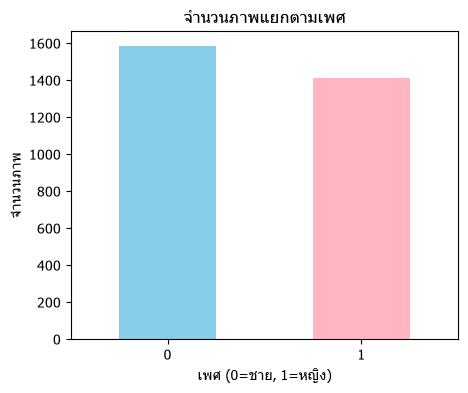

In [20]:
print(df_sample["gender"].value_counts())

plt.figure(figsize=(5,4))
df_sample["gender"].value_counts().plot(kind="bar", color=["skyblue","lightpink"])
plt.title("จำนวนภาพแยกตามเพศ")
plt.xlabel("เพศ (0=ชาย, 1=หญิง)")
plt.ylabel("จำนวนภาพ")
plt.xticks(rotation=0)
plt.show()

ข้อมูลเพศนี้ สมดุลดีมาก (balanced) — ต่างกันแค่ ~6% ไม่เหมือนข้อมูลอายุที่เหลื่อมกันหนักมาก

การเตรียมชุดข้อมูล (Data Preparation) และแบ่งข้อมูล (Data Splitting) สำหรับงานจำแนกเพศ (Gender Classification)

In [21]:
X_clf = pixel_pca                  
y_clf = df_sample["gender"]        

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("จำนวนข้อมูล Train:", X_train_c.shape[0])
print("จำนวนข้อมูล Test:", X_test_c.shape[0])
print("สัดส่วนเพศใน Train:")
print(y_train_c.value_counts(normalize=True))

จำนวนข้อมูล Train: 2400
จำนวนข้อมูล Test: 600
สัดส่วนเพศใน Train:
gender
0    0.52875
1    0.47125
Name: proportion, dtype: float64


#### 2.2 Decision Boundary Visualization  

การเตรียมข้อมูล 2 มิติ (ใช้แค่ 2 PCA components แรก) และ Train โมเดล Logistic Regression บนข้อมูล 2 มิติ แล้ววาด Decision Boundary


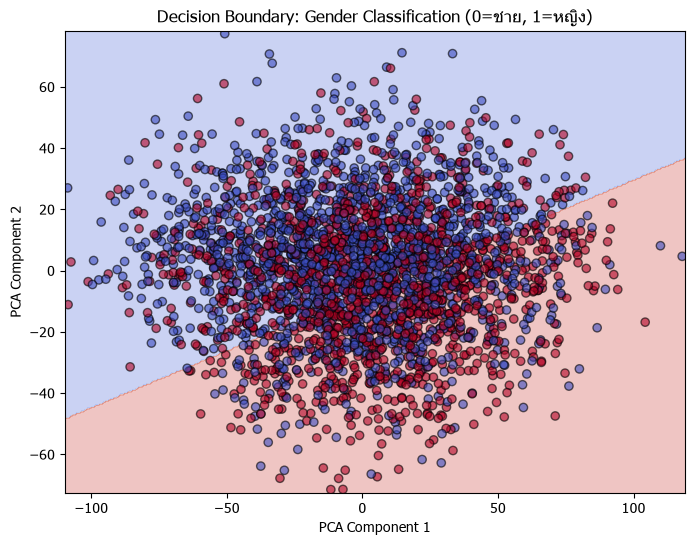

In [22]:
from sklearn.linear_model import LogisticRegression

# เตรียมข้อมูล 2 มิติ (ใช้แค่ PCA component ที่ 1 และ 2)
X_2d = pixel_pca[:, :2]
y_2d = df_sample["gender"].values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

# Train โมเดล Logistic Regression บนข้อมูล 2 มิติ
model_2d = LogisticRegression()
model_2d.fit(X_train_2d, y_train_2d)

# สร้างตารางจุด (mesh grid) ครอบคลุมพื้นที่ข้อมูลทั้งหมด
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

# ให้โมเดลทายทุกจุดใน mesh grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# วาดกราฟ
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_2d, cmap="coolwarm", edgecolor="k", alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Decision Boundary: Gender Classification (0=ชาย, 1=หญิง)")
plt.show()

จะเห็นได้ว่าเส้นแบ่งเขต (Decision Boundary) เป็นเส้นทแยงมุมเฉียงๆ แบ่งพื้นที่เป็นโซนสีฟ้า (ทายชาย) กับสีแดงอมชมพู (ทายหญิง) ชัดเจน — นี่เป็นลักษณะเฉพาะของ Logistic Regression ที่ decision boundary จะเป็นเส้นตรงเสมอ

#### 2.3 Logistic Regression  

การ สร้าง, เทรน (Training), และทดสอบทำนาย (Prediction) โมเดลสำหรับจำแนกเพศด้วย Logistic Regression

In [23]:
model_gender = LogisticRegression(max_iter=1000)
model_gender.fit(X_train_c, y_train_c)

y_pred_c = model_gender.predict(X_test_c)

print("เทรนโมเดลเสร็จแล้ว")
print("จำนวนข้อมูลที่ใช้เทรน:", X_train_c.shape[0], "ภาพ")
print("จำนวน features ที่ใช้:", X_train_c.shape[1], "ตัว (จาก PCA)")

เทรนโมเดลเสร็จแล้ว
จำนวนข้อมูลที่ใช้เทรน: 2400 ภาพ
จำนวน features ที่ใช้: 50 ตัว (จาก PCA)


#### 2.4 Gender Prediction   

การประเมินประสิทธิภาพของโมเดล Gender Classification (ทำนายเพศ) แบบละเอียดครบทุกมิติด้วย Classification Metrics 4 ค่าหลัก

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.8317
Precision: 0.8396
Recall   : 0.7951
F1-score : 0.8167


#### 2.5 Confusion Matrix  

การคำนวณและแสดงผล Confusion Matrix เพื่อประเมินความแม่นยำของโมเดลในการ ทำนายเพศ (Classification)

<Figure size 600x500 with 0 Axes>

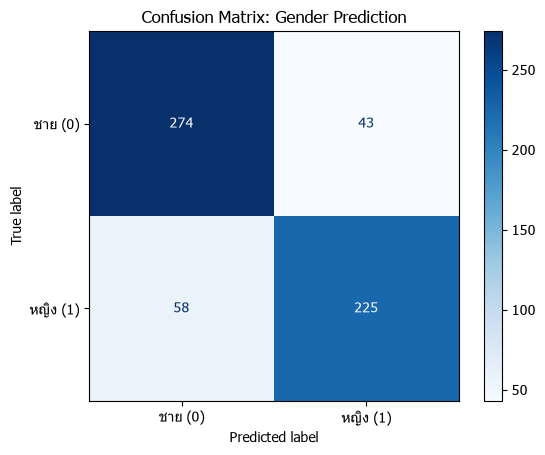

[[274  43]
 [ 58 225]]


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ชาย (0)", "หญิง (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Gender Prediction")
plt.show()

print(cm)

#### LAB 3: Model Comparison 

#### 3.1 Simple vs Multiple Linear Regression  

การ สร้างตารางเปรียบเทียบและพล็อตกราฟแท่ง (Bar Chart) เพื่อวัดประสิทธิภาพของโมเดล Regression ทั้งสองตัว

                              Model  Features ที่ใช้         MSE  R2 Score
0          Simple Linear Regression                1  400.551783  0.022609
1  Multiple Linear Regression (PCA)               50  251.953004  0.385207


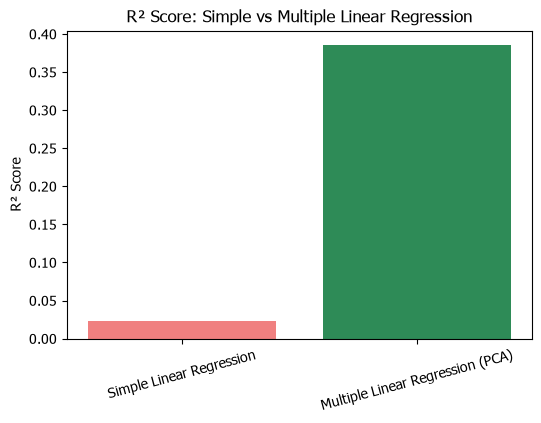

In [26]:
reg_comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression (PCA)"],
    "Features ที่ใช้": [1, 50],
    "MSE": [mean_squared_error(y_test, y_pred), mean_squared_error(y_test_m, y_pred_m)],
    "R2 Score": [r2_score(y_test, y_pred), r2_score(y_test_m, y_pred_m)]
})

print(reg_comparison)

plt.figure(figsize=(6,4))
plt.bar(reg_comparison["Model"], reg_comparison["R2 Score"], color=["lightcoral","seagreen"])
plt.title("R² Score: Simple vs Multiple Linear Regression")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.show()

#### 3.2 Training vs Testing Performance  

การตรวจสอบปัญหา Overfitting / Underfitting โดยการนำผล $R^2$ Score ของ Train set มาเปรียบเทียบกับ Test set แบบคู่ขนาน

                        Model  R2 (Train)  R2 (Test)
0    Simple Linear Regression    0.019842   0.022609
1  Multiple Linear Regression    0.402869   0.385207


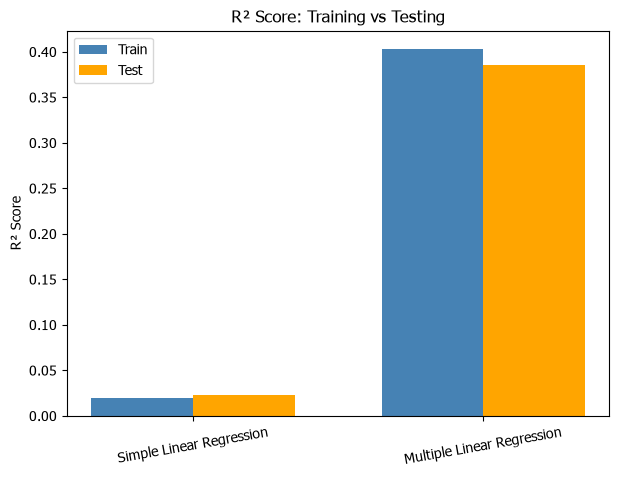

In [27]:
# Simple Linear Regression: วัดผลบน Train set ด้วย
y_train_pred = model.predict(X_train)
r2_train_simple = r2_score(y_train, y_train_pred)
r2_test_simple = r2_score(y_test, y_pred)   # ค่าเดิมที่มีอยู่แล้ว

# Multiple Linear Regression: วัดผลบน Train set ด้วย
y_train_pred_m = model_multi.predict(X_train_m)
r2_train_multi = r2_score(y_train_m, y_train_pred_m)
r2_test_multi = r2_score(y_test_m, y_pred_m)   # ค่าเดิมที่มีอยู่แล้ว

train_test_comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "R2 (Train)": [r2_train_simple, r2_train_multi],
    "R2 (Test)": [r2_test_simple, r2_test_multi]
})
print(train_test_comparison)

# วาดกราฟแท่งเทียบ
x = np.arange(len(train_test_comparison))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, train_test_comparison["R2 (Train)"], width, label="Train", color="steelblue")
plt.bar(x + width/2, train_test_comparison["R2 (Test)"], width, label="Test", color="orange")
plt.xticks(x, train_test_comparison["Model"], rotation=10)
plt.ylabel("R² Score")
plt.title("R² Score: Training vs Testing")
plt.legend()
plt.show()

ทั้งสองโมเดล "ไม่ overfit" เพราะค่า R² ของ Train กับ Test ใกล้เคียงกันมาก (ไม่ใช่ว่า Train สูงปรี๊ดแต่ Test ร่วงหนัก) โดยเฉพาะ Multiple Linear Regression ที่ Train=0.40 และ Test=0.39 ต่างกันแค่ ~0.02 เท่านั้น

#### 3.3 Regression vs Classification  

การสรุปภาพรวมการเปรียบเทียบผลลัพธ์ระหว่างสองโจทย์หลักของโปรเจกต์ครับ คือ การทำนายอายุ (Regression) และ การทำนายเพศ (Classification)

In [28]:
task_comparison = pd.DataFrame({
    "ประเภทงาน": ["Regression (ทายอายุ)", "Classification (ทายเพศ)"],
    "โมเดลที่ใช้": ["Multiple Linear Regression", "Logistic Regression"],
    "ตัวชี้วัดหลัก": ["R² Score", "Accuracy"],
    "ผลลัพธ์": [f"{r2_score(y_test_m, y_pred_m):.4f}", f"{accuracy_score(y_test_c, y_pred_c):.4f}"]
})

print(task_comparison)

                 ประเภทงาน                 โมเดลที่ใช้ ตัวชี้วัดหลัก ผลลัพธ์
0     Regression (ทายอายุ)  Multiple Linear Regression      R² Score  0.3852
1  Classification (ทายเพศ)         Logistic Regression      Accuracy  0.8317


#### 3.4 Model Performance Metrics  

การสรุปผลภาพรวมของทุกโมเดลในโปรเจกต์ และวาดกราฟ ROC Curve พร้อมคำนวณค่า AUC เพื่อประเมินความสามารถในการแยกแยะเพศของโมเดล Classification

                  Model            Task  Metric 1   Value 1  Metric 2  \
0    Simple Linear Reg.      Regression        R2  0.022609       MSE   
1  Multiple Linear Reg.      Regression        R2  0.385207       MSE   
2   Logistic Regression  Classification  Accuracy  0.831667  F1-score   

      Value 2  
0  400.551783  
1  251.953004  
2    0.816697  



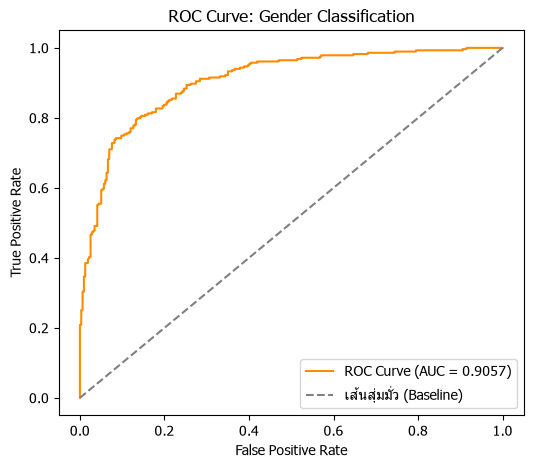

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# ตารางสรุปรวมทุกโมเดล
final_summary = pd.DataFrame({
    "Model": ["Simple Linear Reg.", "Multiple Linear Reg.", "Logistic Regression"],
    "Task": ["Regression", "Regression", "Classification"],
    "Metric 1": ["R2", "R2", "Accuracy"],
    "Value 1": [r2_score(y_test, y_pred), r2_score(y_test_m, y_pred_m), accuracy_score(y_test_c, y_pred_c)],
    "Metric 2": ["MSE", "MSE", "F1-score"],
    "Value 2": [mean_squared_error(y_test, y_pred), mean_squared_error(y_test_m, y_pred_m), f1_score(y_test_c, y_pred_c)]
})
print(final_summary)
print()

# ROC Curve สำหรับ Logistic Regression
y_prob_c = model_gender.predict_proba(X_test_c)[:, 1]   # ความน่าจะเป็นที่จะเป็น "หญิง"
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)
auc_score = roc_auc_score(y_test_c, y_prob_c)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--", label="เส้นสุ่มมั่ว (Baseline)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Gender Classification")
plt.legend()
plt.show()

#### สรุปผล

LAB 1: Regression (ทำนายอายุ)

- เปรียบเทียบ Simple Linear Regression (ใช้ฟีเจอร์เดี่ยว เช่น ความสว่าง) และ Multiple Linear Regression (ใช้ฟีเจอร์จาก PCA) ในการทำนายอายุ

LAB 2: Classification (จำแนกเพศ)

- เตรียมข้อมูล จัดการ Class Imbalance (Stratified Split)

- สร้างโมเดล Logistic Regression เพื่อจำแนกเพศ

- วัดผลด้วย Confusion Matrix, Decision Boundary และ ROC-AUC Curve

LAB 3: Model Comparison (สรุปและเปรียบเทียบผล)

- เปรียบเทียบ Simple vs. Multiple Linear Regression

- เปรียบเทียบประสิทธิภาพบน Training vs. Testing Set เพื่อเช็ก Overfitting

- สรุปความแตกต่างและ Metrics ทั้งหมดของทั้งสองโจทย์ (Regression vs. Classification)

##### นางสาวกวินธิดา สุุขโฉม sec2 116710400602-4